In [1]:
!nvidia-smi

Tue Mar 17 20:02:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torch.optim.optimizer import Optimizer
import matplotlib.pyplot as plt
import time
import pandas as pd

In [3]:
"""
HN_Adam: Hybrid and Adaptive Norming of Adam with AMSGrad — The Modified Algorithm

Implements Algorithm 2, Section 5 from:
    Reyad, M., Sarhan, A. & Arafa, M. "A modified Adam algorithm for deep
    neural network optimization." Neural Comput & Applic 35, 17095-17112 (2023).
    https://doi.org/10.1007/s00521-023-08568-z
"""

class HN_Adam(Optimizer):
    r"""HN_Adam optimizer (Algorithm 2).

    Combines an adaptive norm technique with a hybrid switching mechanism
    between standard Adam and AMSGrad.  The letters "H" and "N" refer to the
    hybrid mechanism and the adaptive norm, respectively.

    Args:
        params (iterable): iterable of parameters to optimize or dicts
            defining parameter groups.
        lr (float): learning rate, step size :math:`\eta` (default: 1e-3).
        betas (Tuple[float, float]): coefficients :math:`(\beta_1, \beta_2)`
            for the exponential moving averages of the gradient and its
            powered absolute value (default: (0.9, 0.999)).
        eps (float): term added to the denominator for numerical stability
            :math:`\epsilon` (default: 1e-8).
        lambda_0 (float or None): initial threshold value of the norm
            :math:`\Lambda_{t_0}`.  When ``None`` it is drawn uniformly from
            [2, 4] as recommended in the paper (default: None).
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 lambda_0=None):
        # ---- validate hyper-parameters ----
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon value: {eps}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 0: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta parameter at index 1: {betas[1]}")

        # Require (Sec. 5): Λₜ₀ is randomly chosen in [2, 4]
        if lambda_0 is None:
            lambda_0 = 2.0 + 2.0 * torch.rand(1).item()  # uniform in [2, 4]
        if lambda_0 <= 0.0:
            raise ValueError(f"Invalid lambda_0 value: {lambda_0}, must be > 0")

        defaults = dict(lr=lr, betas=betas, eps=eps, lambda_0=lambda_0)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        r"""Perform a single optimisation step (Algorithm 2).

        Args:
            closure (callable, optional): a closure that re-evaluates the model
                and returns the loss.

        Returns:
            loss value (if *closure* was supplied).
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        # ---- Algorithm 2: For all t = 1, …, T do ----
        for group in self.param_groups:
            lr = group['lr']
            beta1, beta2 = group['betas']
            eps = group['eps']
            lambda_0 = group['lambda_0']

            for p in group['params']:
                if p.grad is None:
                    continue

                # Step 5:  gₜ ← ∇ loss w.r.t. θₜ₋₁   //  f'(θₜ₋₁)
                grad = p.grad
                if grad.is_sparse:
                    raise RuntimeError(
                        "HN_Adam does not support sparse gradients")

                state = self.state[p]

                # ---- Initialize: m₀=0, v₀=0, amsgrad=False, v̂₍₀₎=0 ----
                if len(state) == 0:
                    state['step'] = 0
                    state['m'] = torch.zeros_like(
                        p, memory_format=torch.preserve_format)
                    state['v'] = torch.zeros_like(
                        p, memory_format=torch.preserve_format)
                    state['v_hat'] = torch.zeros_like(
                        p, memory_format=torch.preserve_format)

                m = state['m']
                v = state['v']
                v_hat = state['v_hat']
                state['step'] += 1

                # Save mₜ₋₁ before the in-place update
                m_prev = m.clone()

                # Step 6:  mₜ ← β₁·mₜ₋₁ + (1 − β₁)·gₜ        // moving average
                m.mul_(beta1).add_(grad, alpha=1.0 - beta1)

                # Step 7:  m_max ← Max(mₜ₋₁ , |gₜ|)
                abs_grad = grad.abs()
                m_max = torch.max(m_prev, abs_grad)
                # Clamp to avoid division by zero when both are zero
                m_max = m_max.clamp(min=eps)

                # Step 8:  Λ(t) ← Λₜ₀ − mₜ₋₁ / m_max            (Eq. 20)
                lambda_t = lambda_0 - m_prev / m_max
                # Clamp to a safe range to prevent extreme exponents
                lambda_t = lambda_t.clamp(min=1.0, max=10.0)

                # Step 9:  vₜ ← β₂·vₜ₋₁ + (1 − β₂)·|gₜ|^{Λ(t)}
                abs_grad_powered = torch.pow(abs_grad + eps, lambda_t)
                v.mul_(beta2).add_(abs_grad_powered, alpha=1.0 - beta2)

                # Precompute 1 / Λ(t) for the denominator exponent
                inv_lambda = 1.0 / lambda_t

                # Step 10: If Λ(t) < 2  →  switch between Adam and AMSGrad
                amsgrad_mask = lambda_t < 2.0

                # Step 12: v̂₍ₜ₎ ← Max(v̂₍ₜ₋₁₎, vₜ)  (AMSGrad branch only)
                v_hat_candidate = torch.max(v_hat, v)
                v_hat.copy_(torch.where(amsgrad_mask, v_hat_candidate, v_hat))

                # Step 13 (AMSGrad branch):
                #   θₜ ← θₜ₋₁ − η · mₜ / ( v̂₍ₜ₎^{1/Λ(t)} + ε )
                denom_amsgrad = torch.pow(
                    v_hat_candidate.clamp(min=0.0), inv_lambda) + eps

                # Step 16 (Adam branch):
                #   θₜ ← θₜ₋₁ − η · mₜ / ( vₜ^{1/Λ(t)} + ε )
                denom_adam = torch.pow(
                    v.clamp(min=0.0), inv_lambda) + eps

                # Element-wise selection of the correct denominator
                denom = torch.where(amsgrad_mask, denom_amsgrad, denom_adam)

                # Apply parameter update:
                #   θₜ ← θₜ₋₁ − η · mₜ / denom
                p.addcdiv_(m, denom, value=-lr)

        # Step 18: return final parameter θ_T
        return loss

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CNN architecture matching the paper description
class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 28x28 -> 28x28
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  # 28x28 -> 28x28
            nn.MaxPool2d(kernel_size=2, stride=2),        # 28x28 -> 14x14
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 14x14 -> 14x14
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # 14x14 -> 14x14
            nn.MaxPool2d(kernel_size=2, stride=2),        # 14x14 -> 7x7
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((4, 4))                  # 64x4x4 (1024)
        )

        self.flatten = nn.Flatten()  # 64*4*4 = 1024

        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.1),

            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.1),

            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.1),

            nn.Linear(256, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.1),

            nn.Linear(32, 10),
        )
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        logits = self.classifier(x)
        probs = self.softmax(logits)
        return probs

# Model + parameter check
model = DeepCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
assert total_params == 697034, f"Expected 697034 parameters, got {total_params}"

Total parameters: 697034


In [6]:
# MNIST in float32, normalized to [0, 1]
transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# 40k train, 10k validation, 10k test
train_subset = Subset(mnist_train, range(0, 40000))
val_subset = Subset(mnist_train, range(40000, 50000))
test_subset = mnist_test

batch_size = 128
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 441kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [7]:
# Adam settings: beta1=0.9, beta2=0.99, eps=1e-8, lr=0.001
optimizer = optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.99), eps=1e-8)
criterion = nn.NLLLoss()  # because model returns Softmax probabilities

num_epochs = 20
train_losses, train_accuracies, val_accuracies = [], [], []

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        probs = model(images)
        loss = criterion(torch.log(probs + 1e-12), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = probs.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            probs = model(images)
            preds = probs.argmax(dim=1)
            v_total += labels.size(0)
            v_correct += (preds == labels).sum().item()

    val_acc = v_correct / v_total
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

training_time = time.time() - start_time

Epoch [1/20] - Loss: 0.6082, Train Acc: 0.7914, Val Acc: 0.9598
Epoch [2/20] - Loss: 0.1387, Train Acc: 0.9611, Val Acc: 0.9660
Epoch [3/20] - Loss: 0.0954, Train Acc: 0.9736, Val Acc: 0.9582
Epoch [4/20] - Loss: 0.0788, Train Acc: 0.9788, Val Acc: 0.9811
Epoch [5/20] - Loss: 0.0649, Train Acc: 0.9821, Val Acc: 0.9846
Epoch [6/20] - Loss: 0.0536, Train Acc: 0.9854, Val Acc: 0.9848
Epoch [7/20] - Loss: 0.0465, Train Acc: 0.9878, Val Acc: 0.9867
Epoch [8/20] - Loss: 0.0364, Train Acc: 0.9897, Val Acc: 0.9856
Epoch [9/20] - Loss: 0.0343, Train Acc: 0.9902, Val Acc: 0.9865
Epoch [10/20] - Loss: 0.0299, Train Acc: 0.9913, Val Acc: 0.9882
Epoch [11/20] - Loss: 0.0289, Train Acc: 0.9918, Val Acc: 0.9854
Epoch [12/20] - Loss: 0.0247, Train Acc: 0.9927, Val Acc: 0.9898
Epoch [13/20] - Loss: 0.0240, Train Acc: 0.9935, Val Acc: 0.9845
Epoch [14/20] - Loss: 0.0221, Train Acc: 0.9938, Val Acc: 0.9883
Epoch [15/20] - Loss: 0.0214, Train Acc: 0.9942, Val Acc: 0.9864
Epoch [16/20] - Loss: 0.0177, Trai

In [8]:
# Test
model.eval()
t_correct, t_total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        probs = model(images)
        preds = probs.argmax(dim=1)
        t_total += labels.size(0)
        t_correct += (preds == labels).sum().item()

test_accuracy = t_correct / t_total

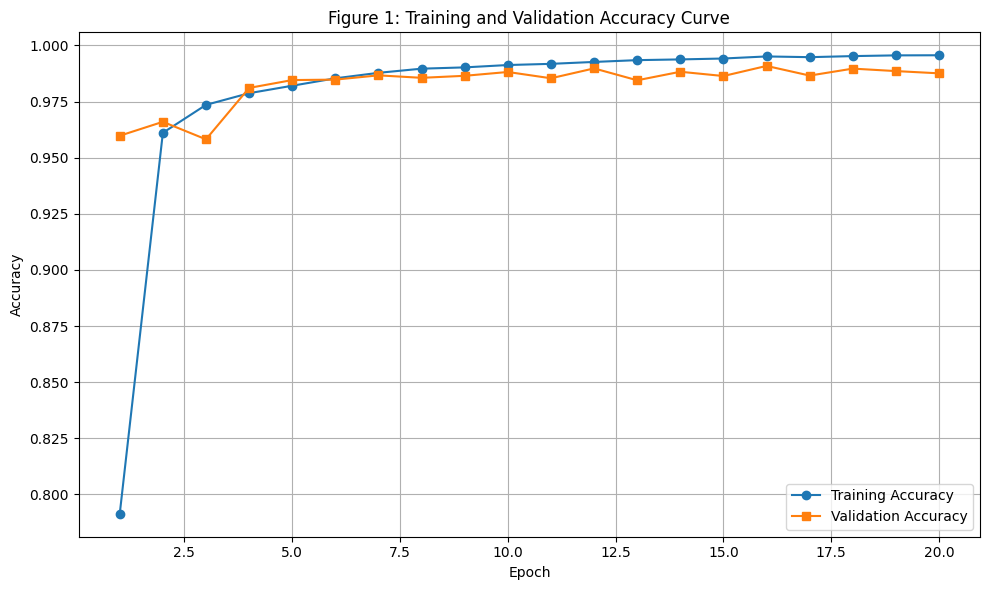

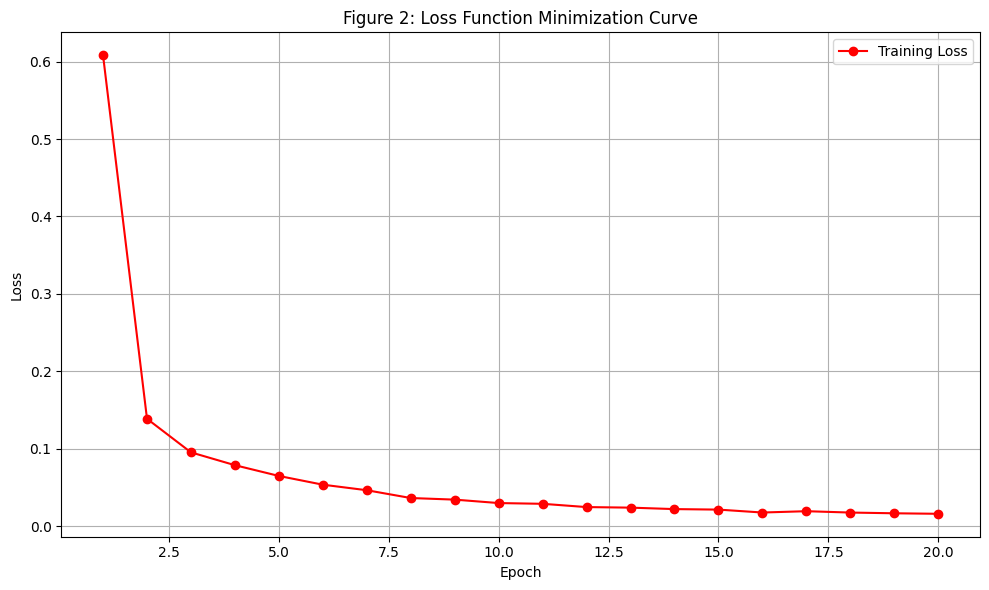


Table 1: Training Results Summary
                 Metric    Value
  Minimum Training Loss 0.016032
       Testing Accuracy 0.992200
Training Time (seconds)   171.26


In [9]:
# Figure 1: Accuracy curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_accuracies, marker="o", label="Training Accuracy")
plt.plot(range(1, num_epochs + 1), val_accuracies, marker="s", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Figure 1: Training and Validation Accuracy Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Loss minimization curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", color="red", label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Figure 2: Loss Function Minimization Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Table 1
results_df = pd.DataFrame({
    "Metric": ["Minimum Training Loss", "Testing Accuracy", "Training Time (seconds)"],
    "Value": [f"{min(train_losses):.6f}", f"{test_accuracy:.6f}", f"{training_time:.2f}"]
})
print("\nTable 1: Training Results Summary")
print(results_df.to_string(index=False))